In [1]:
# [1] 라이브러리
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [2]:
import numpy as np
import pandas as pd

cas = pd.read_csv("/Users/oseli/Desktop/FOM/conference/summer_conference/open/CAS_clean.csv")
cas = cas[cas['Assay Parameter'].str.lower().isin(['ic50'])].copy()
cas = cas.rename(columns={'pX Value': 'pIC50'})
cas = cas[['SMILES', 'pIC50']]
cas['Source'] = 'CAS'  

pub = pd.read_csv("/Users/oseli/Desktop/FOM/conference/summer_conference/open/Pubchem_ASK1.csv", low_memory=False)
pub = pub[pub['Activity_Type'].str.lower().isin(['ic50', 'ki', 'kd'])].copy()
pub = pub[pub['Activity_Value'] > 0].copy()
pub['pIC50'] = -np.log10(pub['Activity_Value'])
pub = pub[['SMILES', 'pIC50']]
pub['Source'] = 'PubChem'  

chem = pd.read_csv("/Users/oseli/Desktop/FOM/conference/summer_conference/open/ChEMBL_ASK1(IC50).csv", sep=';')
chem = chem[['Smiles', 'pChEMBL Value']].dropna()
chem = chem.rename(columns={'Smiles': 'SMILES', 'pChEMBL Value': 'pIC50'})
chem['Source'] = 'ChEMBL'  

# 데이터 합치기
df = pd.concat([cas, pub, chem], ignore_index=True).drop_duplicates('SMILES').reset_index(drop=True)

print(df.head())
print(df['Source'].value_counts())


#pub, chem 1145
#cas 까지 3844

                                              SMILES    pIC50 Source
0  O[C@H]1[C@H](N2C=3C(N=C2)=C(N)N=CN3)O[C@H](COP...  5.61380    CAS
1                         S(C)C1=C2C(=NC(N)=N1)N=CN2  4.87615    CAS
2                  N(C1=C2C(N=CN2)=NC=N1)C3=CC=CC=C3  5.00000    CAS
3                        C12=C(N=CN=C1N=CN2)N3CCCCC3  4.76955    CAS
4   C(C)(=O)C1=C2C=3C(C(=O)C=4C2=CC=CC4)=CC=CC3NC1=O  4.82391    CAS
Source
CAS        2339
PubChem     758
ChEMBL      383
Name: count, dtype: int64


In [3]:
from rdkit import Chem
from rdkit.Chem import MolToSmiles
import pandas as pd
import numpy as np

def smiles_augmentation(smiles, n_aug=5):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return []
    aug_smiles = set()
    for _ in range(n_aug):
        aug = Chem.MolToSmiles(mol, doRandom=True)
        aug_smiles.add(aug)
    return list(aug_smiles)

def augment_df(df, target_size):
    current_size = len(df)
    n_augment_per_sample = max(1, int(target_size / current_size) - 1)
    
    new_rows = []
    for idx, row in df.iterrows():
        aug_smiles_list = smiles_augmentation(row['SMILES'], n_aug=n_augment_per_sample)
        for aug_smiles in aug_smiles_list:
            new_rows.append({'SMILES': aug_smiles, 'pIC50': row['pIC50'], 'Source': row['Source']})
    augmented_df = pd.DataFrame(new_rows)
    
    # 원본 + 증강 데이터 합치기
    combined_df = pd.concat([df, augmented_df], ignore_index=True)
    
    # 필요한 경우 target_size로 잘라내기
    if len(combined_df) > target_size:
        combined_df = combined_df.sample(n=target_size, random_state=42).reset_index(drop=True)
    
    return combined_df

# CAS 데이터 개수
target_size = 2339

# PubChem 증강
pub_df = df[df['Source'] == 'PubChem']
pub_augmented = augment_df(pub_df, target_size)

# ChEMBL 증강
chem_df = df[df['Source'] == 'ChEMBL']
chem_augmented = augment_df(chem_df, target_size)

# CAS는 그대로
cas_df = df[df['Source'] == 'CAS']

# 최종 합치기
df = pd.concat([cas_df, pub_augmented, chem_augmented], ignore_index=True)
print(df['Source'].value_counts())
print(f"Total samples after augmentation: {len(df)}")


Source
CAS        2339
ChEMBL     2297
PubChem    2274
Name: count, dtype: int64
Total samples after augmentation: 6910


In [3]:
from rdkit import Chem
from rdkit.Chem import Descriptors
import pandas as pd
import numpy as np

def calc_features(smiles, pIC50):
    if not isinstance(smiles, str):
        return pd.Series({
            'MolWt': np.nan,
            'TPSA': np.nan,
            'LogP': np.nan,
            'NumHDonors': np.nan,
            'NumHAcceptors': np.nan,
            'LE': np.nan,
            'BEI': np.nan,
            'LLE': np.nan,
            'TPSA_per_MolWt': np.nan
        })
    
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return pd.Series({
            'MolWt': np.nan,
            'TPSA': np.nan,
            'LogP': np.nan,
            'NumHDonors': np.nan,
            'NumHAcceptors': np.nan,
            'LE': np.nan,
            'BEI': np.nan,
            'LLE': np.nan,
            'TPSA_per_MolWt': np.nan
        })
    
    MolWt = Descriptors.MolWt(mol)
    TPSA = Descriptors.TPSA(mol)
    LogP = Descriptors.MolLogP(mol)
    NumHDonors = Descriptors.NumHDonors(mol)
    NumHAcceptors = Descriptors.NumHAcceptors(mol)
    
    if pIC50 is not None and not np.isnan(pIC50):
        IC50 = 10 ** (-pIC50)
        if MolWt != 0:
            LE = -np.log10(IC50) / MolWt
            BEI = -np.log10(IC50) / (MolWt / 1000)
        else:
            LE = np.nan
            BEI = np.nan
        LLE = -np.log10(IC50) - LogP
    else:
        LE = np.nan
        BEI = np.nan
        LLE = np.nan
    
    TPSA_per_MolWt = TPSA / MolWt if MolWt != 0 else np.nan
    
    return pd.Series({
        'MolWt': MolWt,
        'TPSA': TPSA,
        'LogP': LogP,
        'NumHDonors': NumHDonors,
        'NumHAcceptors': NumHAcceptors,
        'LE': LE,
        'BEI': BEI,
        'LLE': LLE,
        'TPSA_per_MolWt': TPSA_per_MolWt
    })

# 예시: df에 적용
df_features = df.copy()
features = df_features.apply(lambda row: calc_features(row['SMILES'], row['pIC50']), axis=1)
df_features = pd.concat([df_features, features], axis=1)

print(df_features.head())


                                              SMILES    pIC50 Source    MolWt  \
0  O[C@H]1[C@H](N2C=3C(N=C2)=C(N)N=CN3)O[C@H](COP...  5.61380    CAS  507.182   
1                         S(C)C1=C2C(=NC(N)=N1)N=CN2  4.87615    CAS  181.224   
2                  N(C1=C2C(N=CN2)=NC=N1)C3=CC=CC=C3  5.00000    CAS  211.228   
3                        C12=C(N=CN=C1N=CN2)N3CCCCC3  4.76955    CAS  203.249   
4   C(C)(=O)C1=C2C=3C(C(=O)C=4C2=CC=CC4)=CC=CC3NC1=O  4.82391    CAS  289.290   

     TPSA    LogP  NumHDonors  NumHAcceptors        LE        BEI      LLE  \
0  279.13 -1.6290         7.0           14.0  0.011069  11.068610  7.24280   
1   80.48  0.6570         2.0            5.0  0.026907  26.906756  4.21915   
2   66.49  2.0965         2.0            4.0  0.023671  23.671104  2.90350   
3   57.70  1.3432         1.0            4.0  0.023467  23.466536  3.42635   
4   67.00  2.9421         1.0            3.0  0.016675  16.674997  1.88181   

   TPSA_per_MolWt  
0        0.550355  
1   

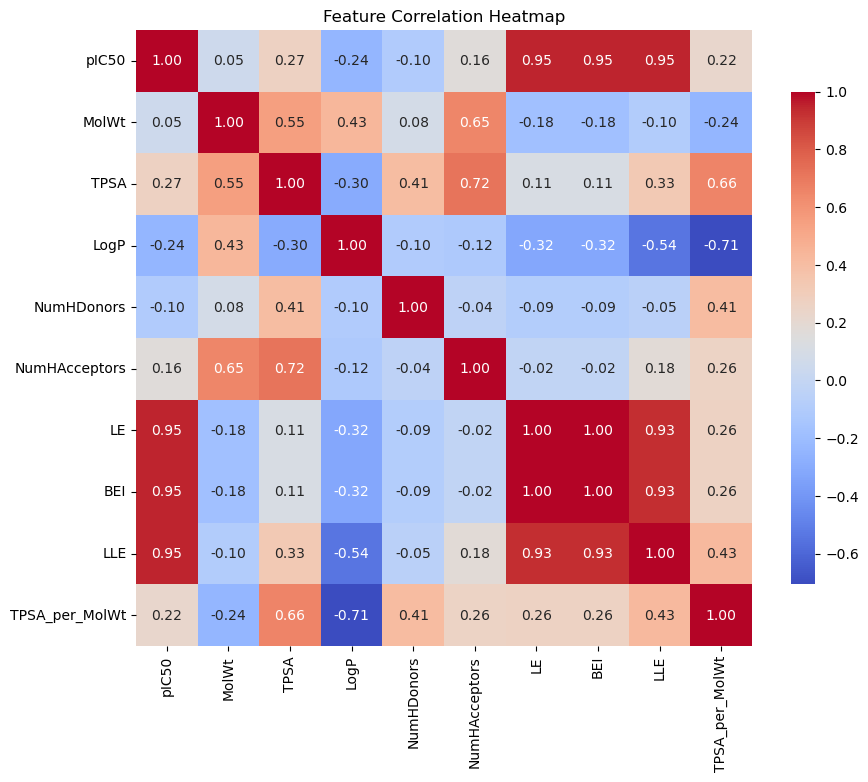

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# 피처들만 뽑기 (숫자형 컬럼)
feature_cols = ['pIC50','MolWt', 'TPSA', 'LogP', 'NumHDonors', 'NumHAcceptors', 'LE', 'BEI', 'LLE', 'TPSA_per_MolWt']

corr = df_features[feature_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Feature Correlation Heatmap')
plt.show()

#LE 0.95
#BEI 0.95
#LLE 0.95
#TPSA_per_MolWt 0.27
#LOGp -0.24

# TPSA_per_MolWt, 'LE', 'BEI', 'LLE',LogP

In [5]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

def normalized_rmse(y_true, y_pred):
    # A: IC50 (nM) 단위의 Normalized RMSE
    # IC50 = 10^(-pIC50), y_true, y_pred는 pIC50 값
    IC50_true = 10 ** (-y_true)
    IC50_pred = 10 ** (-y_pred)
    
    rmse = np.sqrt(mean_squared_error(IC50_true, IC50_pred))
    norm_rmse = rmse / (IC50_true.max() - IC50_true.min())
    norm_rmse = min(norm_rmse, 1)  # 문제 정의에 따라 1으로 캡핑
    return norm_rmse

def combined_score(y_true, y_pred):
    A = normalized_rmse(y_true, y_pred)
    B = r2_score(y_true, y_pred)
    score = 0.4 * (1 - A) + 0.6 * B
    return score, A, B


In [6]:
df_features = df_features.dropna(subset=feature_cols + ['pIC50', 'SMILES', 'Source'])
print(f"Rows after dropna: {len(df_features)}")
print(df_features[feature_cols + ['pIC50']].isna().sum())


Rows after dropna: 3470
pIC50             0
MolWt             0
TPSA              0
LogP              0
NumHDonors        0
NumHAcceptors     0
LE                0
BEI               0
LLE               0
TPSA_per_MolWt    0
pIC50             0
dtype: int64


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

feature_cols = ['TPSA', 'LE', 'BEI', 'LLE', 'LogP']

# 1. 출처 원-핫 인코딩
df_features_clean = df_features.dropna(subset=feature_cols + ['pIC50', 'Source', 'SMILES']).copy()
df_features_clean = pd.get_dummies(df_features_clean, columns=['Source'])

# 2. 피처, 타겟 분리
feature_cols_extended = feature_cols + [col for col in df_features_clean.columns if col.startswith('Source_')]
X = df_features_clean[feature_cols_extended]
y = df_features_clean['pIC50']

# 3. NaN 있을 경우 평균값으로 대체 (안전하게)
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

# 4. 출처별 가중치 매핑
weight_map = {
    'Source_CAS': 1.0,
    'Source_PubChem': 1.5,
    'Source_ChEMBL': 1.5
}

# 원-핫 인코딩 상태에서 각 행이 어떤 출처인지 판별해서 가중치 적용
# 각 행에서 Source 컬럼별 값 중 1인 컬럼을 찾아서 매핑
sample_weights = []
for idx, row in df_features_clean.iterrows():
    w = 0
    for src_col in weight_map.keys():
        if row.get(src_col, 0) == 1:
            w = weight_map[src_col]
            break
    sample_weights.append(w)
sample_weights = np.array(sample_weights)

# 5. train/test split
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X_imputed, y, sample_weights, test_size=0.4, random_state=42)

# 6. 평가 함수 정의
def normalized_rmse(y_true, y_pred):
    IC50_true = 10 ** (-y_true)
    IC50_pred = 10 ** (-y_pred)
    rmse = np.sqrt(mean_squared_error(IC50_true, IC50_pred))
    norm_rmse = rmse / (IC50_true.max() - IC50_true.min())
    return min(norm_rmse, 1)

def combined_score(y_true, y_pred):
    A = normalized_rmse(y_true, y_pred)
    B = r2_score(y_true, y_pred)
    return 0.4 * (1 - A) + 0.6 * B, A, B

# 7. 랜덤포레스트 학습 및 평가
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train, sample_weight=w_train)
y_pred_rf = rf.predict(X_test)
score_rf, A_rf, B_rf = combined_score(y_test, y_pred_rf)
print(f"Random Forest - Score: {score_rf:.4f}, Normalized RMSE: {A_rf:.4f}, R^2: {B_rf:.4f}")

# 8. XGBoost 학습 및 평가
xgbr = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
xgbr.fit(X_train, y_train, sample_weight=w_train)
y_pred_xgb = xgbr.predict(X_test)
score_xgb, A_xgb, B_xgb = combined_score(y_test, y_pred_xgb)
print(f"XGBoost - Score: {score_xgb:.4f}, Normalized RMSE: {A_xgb:.4f}, R^2: {B_xgb:.4f}")


In [ ]:
import pandas as pd
import numpy as np

# ====== pIC50 → IC50 변환 함수 ======
def pIC50_to_IC50_nM(pIC50):
    return 10 ** (9 - pIC50)

# ====== 테스트 데이터 로드 ======
test_df = pd.read_csv("/Users/oseli/Desktop/FOM/conference/data/open/test.csv")

# ====== Source one-hot 인코딩 (학습과 동일하게) ======
test_df = pd.get_dummies(test_df, columns=['Source'])

# 학습 때 사용한 feature_cols_extended 순서에 맞춰서 피처 정렬
for col in feature_cols_extended:
    if col not in test_df.columns:
        test_df[col] = 0  # 없는 컬럼은 0으로 채움
X_test_final = imputer.transform(test_df[feature_cols_extended].astype(float))

# ====== 1. RandomForest 예측 ======
y_pred_rf_pIC50 = rf.predict(X_test_final)
y_pred_rf_IC50_nM = pIC50_to_IC50_nM(y_pred_rf_pIC50)

submission_rf = pd.DataFrame({
    "ID": test_df["ID"],
    "ASK1_IC50_nM": y_pred_rf_IC50_nM
})
submission_rf.to_csv("submission_rf.csv", index=False)
print("✅ submission_rf.csv 저장 완료!")

# ====== 2. XGBoost 예측 ======
y_pred_xgb_pIC50 = xgbr.predict(X_test_final)
y_pred_xgb_IC50_nM = pIC50_to_IC50_nM(y_pred_xgb_pIC50)

submission_xgb = pd.DataFrame({
    "ID": test_df["ID"],
    "ASK1_IC50_nM": y_pred_xgb_IC50_nM
})
submission_xgb.to_csv("submission_xgb.csv", index=False)
print("✅ submission_xgb.csv 저장 완료!")


In [ ]:
import pandas as pd
import numpy as np

# ====== pIC50 → IC50 변환 함수 ======
def pIC50_to_IC50_nM(pIC50):
    return 10 ** (9 - pIC50)

# ====== 테스트 데이터 로드 ======
test_df = pd.read_csv("/Users/oseli/Desktop/FOM/conference/data/open/test.csv")

# ====== Source one-hot 인코딩 (학습과 동일하게) ======
test_df = pd.get_dummies(test_df, columns=['Source'])

# 학습 때 사용한 feature_cols_extended 순서에 맞춰서 피처 정렬
for col in feature_cols_extended:
    if col not in test_df.columns:
        test_df[col] = 0  # 없는 컬럼은 0으로 채움
X_test_final = imputer.transform(test_df[feature_cols_extended].astype(float))

# ====== 예측 ======
y_pred_rf = rf.predict(X_test_final)
y_pred_xgb = xgbr.predict(X_test_final)

# 앙상블 (평균)
y_pred_pIC50 = (y_pred_rf + y_pred_xgb) / 2

# ====== pIC50 → IC50 변환 ======
y_pred_IC50_nM = pIC50_to_IC50_nM(y_pred_pIC50)

# ====== 제출 파일 생성 ======
submission = pd.DataFrame({
    "ID": test_df["ID"],
    "ASK1_IC50_nM": y_pred_IC50_nM
})
submission.to_csv("submission.csv", index=False)

print("✅ submission.csv 저장 완료!")
